# HaGRID --- Gesture Classification Training
### EfficientNet-B0 · PyTorch · Google Colab

**Dataset:** [`GestureDetectionConnoisseurs/hagrid_subsets`](https://huggingface.co/datasets/GestureDetectionConnoisseurs/hagrid_subsets/tree/main)  
Pre-packaged subsets of the HaGRID dataset — choose 5 / 100 / 500 / 1000 / 2000 images per class.  
No Kaggle account, no SberCloud — just a direct HuggingFace download.
---

### What this notebook does
| Step | Description |
|---|---|
| 1 | Environment setup and GPU check |
| 2 | Configuration |
| 3 | Load dataset from HuggingFace (34-class HaGRIDv2 subset, balanced) |
| 4 | Build PyTorch Dataset and DataLoaders |
| 5 | Fine-tune EfficientNet-B0 (34-class gesture classification) |
| 6 | Training loop with LR scheduling and early stopping |
| 7 | Training curves |
| 8 | Evaluation --- accuracy, per-class F1, confusion matrix |
| 9 | Inference demo on random validation images |
| 10 | Save model checkpoint and export to Google Drive |

### 34 Classes (HaGRIDv2)
`call` · `dislike` · `fist` · `four` · `grabbing` · `grip` · `hand_heart` · `hand_heart2` · `holy` · `like` · `little_finger` · `middle_finger` · `mute` · `no_gesture` · `ok` · `one` · `palm` · `peace` · `peace_inverted` · `point` · `rock` · `stop` · `stop_inverted` · `take_picture` · `three` · `three2` · `three3` · `three_gun` · `thumb_index` · `thumb_index2` · `timeout` · `two_up` · `two_up_inverted` · `xsign`

---
<a id='1'></a>
## 1. Environment Setup

In [ ]:
import subprocess, sys

try:
    import google.colab
    IN_COLAB = True
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    print('Not on Colab --- paths may need adjustment')

#GPU check
try:
    gpu_info = subprocess.check_output('nvidia-smi', shell=True).decode()
    print('[GPU]', gpu_info.split('\n')[8].strip())
except Exception:
    print('[WARN] No GPU detected --- training will be slow on CPU')

#Disk space
print(subprocess.check_output('df -h /content', shell=True).decode())

Running on Google Colab
[GPU] |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   43G  193G  19% /



In [ ]:
!pip install -q timm scikit-learn matplotlib seaborn tqdm datasets onnxscript onnx onnxruntime

import os, random, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from sklearn.metrics import classification_report, confusion_matrix, f1_score

#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'All imports OK')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 8.1 MB/s eta 0:00:00
All imports OK
Device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


---
<a id='2'></a>
## 2. Configuration

> Tune these before running the rest of the notebook.

In [ ]:
#Model
MODEL_NAME     = 'efficientnet_b0'
IMG_SIZE       = 224

#Training
BATCH_SIZE     = 64
NUM_EPOCHS     = 100
LR             = 3e-4
WEIGHT_DECAY   = 1e-4
PATIENCE       = 8
FREEZE_BASE    = True
UNFREEZE_EPOCH = 3

#ImageNet normalisation (EfficientNet-B0 pretrained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

#Paths
CONTENT_DIR = Path('/content')
CKPT_DIR    = CONTENT_DIR / 'hagrid_checkpoints'

#Output subfolders: plots/ for images, metrics/ for JSON logs
PLOTS_DIR   = CONTENT_DIR / 'hagrid_outputs' / 'plots'
METRICS_DIR = CONTENT_DIR / 'hagrid_outputs' / 'metrics'

for d in [CKPT_DIR, PLOTS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuration summary:')
print(f'  Model          : {MODEL_NAME}')
print(f'  Image size     : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Epochs         : {NUM_EPOCHS} (patience={PATIENCE})')
print(f'  Learning rate  : {LR}')
print(f'  Unfreeze epoch : {UNFREEZE_EPOCH}')
print(f'  Device         : {DEVICE}')
print(f'  Plots dir      : {PLOTS_DIR}')
print(f'  Metrics dir    : {METRICS_DIR}')


Configuration summary:
  Model          : efficientnet_b0
  Image size     : 224x224
  Batch size     : 64
  Epochs         : 100 (patience=8)
  Learning rate  : 0.0003
  Unfreeze epoch : 3
  Device         : cuda
  Plots dir      : /content/hagrid_outputs/plots
  Metrics dir    : /content/hagrid_outputs/metrics


---
<a id='3'></a>
## 3. Load Dataset

Uses `GestureDetectionConnoisseurs/hagrid_subsets` from HuggingFace --- a pre-balanced subset of HaGRIDv2 with images already loaded as PIL. No manual downloading or ZIP parsing needed.

The full dataset object contains multiple subset sizes (5, 100, 500, 1000, 2000 images per class). All are merged here and then split 80/10/10 by subject to avoid leakage.

In [ ]:
from datasets import load_dataset
from collections import defaultdict, Counter

print('Loading HaGRID 500-per-class zip...')
ds_raw = load_dataset(
    'GestureDetectionConnoisseurs/hagrid_subsets',
    data_files={'train': 'hagrid-export_500_images.zip'}
)
ds_subset = ds_raw['train']
print(f'Loaded: {len(ds_subset):,} samples')

Loading HaGRID 500-per-class zip...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/243 [00:00<?, ?B/s]

hagrid-export_500_images.zip:   0%|          | 0.00/2.03G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded: 17,000 samples


In [ ]:
#Class mapping
ALL_CLASSES = ds_subset.features['label'].names
CLASS2IDX   = {c: i for i, c in enumerate(ALL_CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(ALL_CLASSES)
print(f'Classes: {NUM_CLASSES}')

#Verify balance
label_counts = Counter(ds_subset['label'])
count_items  = sorted(label_counts.items())
print(f'Samples per class: min={min(v for _,v in count_items)}  max={max(v for _,v in count_items)}')

Classes: 34
Samples per class: min=500  max=500


In [ ]:
#Mount Google Drive
import cv2
from google.colab import drive
drive.mount('/content/drive')

CACHE_DIR  = Path('/content/drive/MyDrive/hagrid_dataset')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / 'hagrid_500_cache.npz'

if CACHE_PATH.exists():
    print('Loading from Drive cache...')
    data       = np.load(CACHE_PATH)
    all_images = data['images']
    all_labels = data['labels']
    print(f'Cache loaded. Shape: {all_images.shape}')
else:
    print('Building cache (one-time, saving to Drive)...')
    hf         = ds_subset.with_format('numpy')
    imgs       = hf['image']
    all_images = np.stack([
        cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)
        for img in tqdm(imgs)
    ])
    all_labels = np.array(hf['label'])
    np.savez_compressed(CACHE_PATH, images=all_images, labels=all_labels)
    print(f'Done. Saved to {CACHE_PATH}')
    print(f'Shape: {all_images.shape}  RAM: {all_images.nbytes / 1e9:.2f} GB')

Mounted at /content/drive
Loading from Drive cache...
Cache loaded. Shape: (17000, 128, 128, 3)


In [ ]:
#Shuffle and split 80 / 10 / 10
np.random.seed(SEED)
idx        = np.random.permutation(len(all_images))
n          = len(idx)
train_end  = int(n * 0.80)
val_end    = int(n * 0.90)

train_images, train_labels = all_images[idx[:train_end]],  all_labels[idx[:train_end]]
val_images,   val_labels   = all_images[idx[train_end:val_end]], all_labels[idx[train_end:val_end]]
test_images,  test_labels  = all_images[idx[val_end:]],    all_labels[idx[val_end:]]

print(f'Train: {len(train_images):,} | Val: {len(val_images):,} | Test: {len(test_images):,}')

Train: 13,600 | Val: 1,700 | Test: 1,700


---
<a id='4'></a>
## 4. Dataset and DataLoaders

In [ ]:
#Training: augmentation to improve generalisation
#Val/Test: deterministic resize only
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


In [ ]:
class HaGRIDDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images       #numpy array (N, 128, 128, 3)
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

train_ds = HaGRIDDataset(train_images, train_labels, transform=train_transform)
val_ds   = HaGRIDDataset(val_images,   val_labels,   transform=val_transform)
test_ds  = HaGRIDDataset(test_images,  test_labels,  transform=val_transform)

#num_workers=2 avoids shared-memory issues on Colab
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f'Train : {len(train_ds):,} samples | {len(train_loader)} batches')
print(f'Val   : {len(val_ds):,} samples | {len(val_loader)} batches')
print(f'Test  : {len(test_ds):,} samples | {len(test_loader)} batches')

Train : 13,600 samples | 213 batches
Val   : 1,700 samples | 27 batches
Test  : 1,700 samples | 27 batches


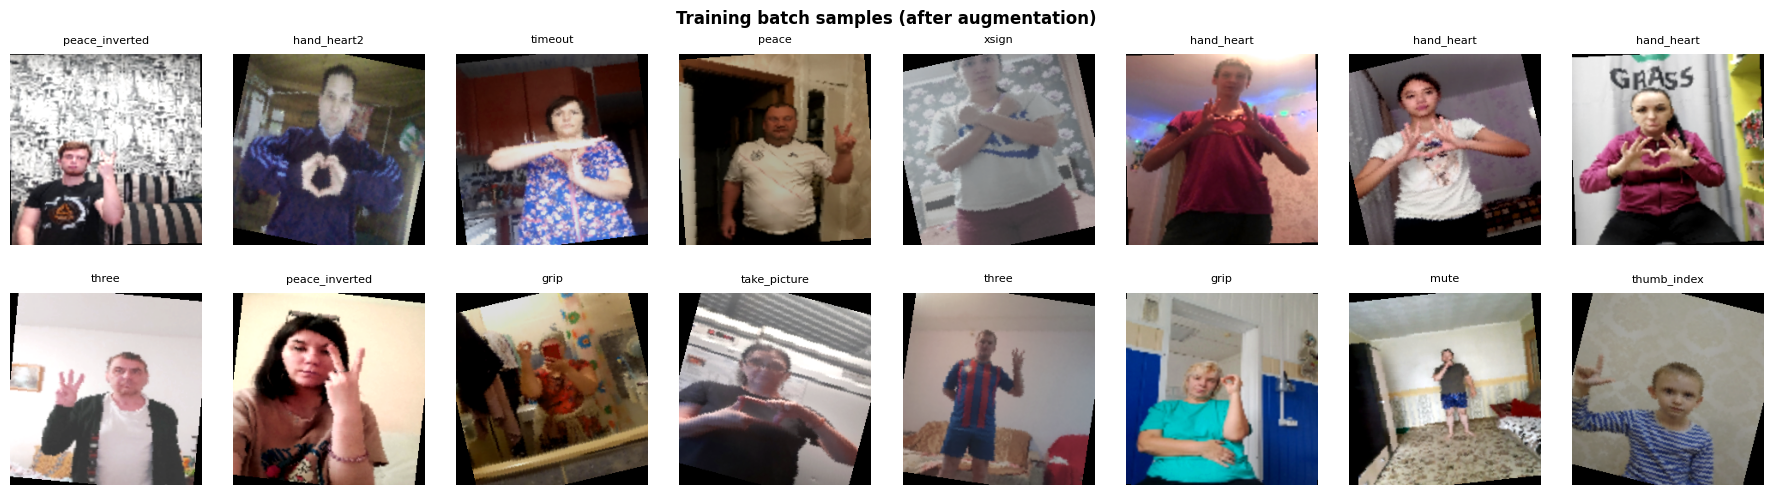

In [ ]:
#Visualise a sample batch after augmentation
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))
n_show = min(16, len(imgs))

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
axes = axes.flatten()
for i in range(n_show):
    img_np = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(IDX2CLASS[labels[i].item()], fontsize=8, pad=8)
    axes[i].axis('off')
plt.suptitle('Training batch samples (after augmentation)', fontweight='bold')
plt.tight_layout(h_pad=4)
plt.savefig(PLOTS_DIR / 'sample_batch.png', bbox_inches='tight')
plt.show()

---
<a id='5'></a>
## 5. Model --- EfficientNet-B0

EfficientNet-B0 pretrained on ImageNet, adapted to 34-class gesture classification.

Training strategy:
- Epochs 1-2: backbone frozen, only the classifier head trains. This lets the new head stabilise before gradients flow through the pretrained layers.
- Epoch 3 onwards: full fine-tuning with a 10x lower LR for the backbone to avoid destroying pretrained features.

In [ ]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

def set_backbone_grad(model, requires_grad: bool):
    """Freeze or unfreeze all layers except the classifier head."""
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = requires_grad

if FREEZE_BASE:
    set_backbone_grad(model, requires_grad=False)
    print('Backbone frozen --- training classifier head only.')

model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel            : {MODEL_NAME}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print(f'Frozen params    : {total_params - trainable_params:,}')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone frozen --- training classifier head only.

Model            : efficientnet_b0
Total params     : 4,051,102
Trainable params : 43,554
Frozen params    : 4,007,548


---
<a id='6'></a>
## 6. Training Loop

In [ ]:
#Dataset is perfectly balanced (500 samples per class) so no class weights needed.
#Label smoothing 0.1 reduces overconfidence on similar gestures (e.g. three / three2 / three3).
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

#Cosine annealing restarts every T_0=5 epochs, period doubles each restart
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-6
)

print('Loss      : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})')
print('Scheduler : CosineAnnealingWarmRestarts (T_0=5, T_mult=2)')

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler : CosineAnnealingWarmRestarts (T_0=5, T_mult=2)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


print('Training helpers defined.')

Training helpers defined.


In [ ]:

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

best_val_acc     = 0.0
patience_counter = 0
#Single checkpoint file — no redundant resave later
best_ckpt_path   = CKPT_DIR / f'{MODEL_NAME}_hagrid_final.pth'

print('=' * 60)
print(f'  Starting training --- {NUM_EPOCHS} epochs | device: {DEVICE}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    #Unfreeze backbone at UNFREEZE_EPOCH with differential LR
    if FREEZE_BASE and epoch == UNFREEZE_EPOCH:
        set_backbone_grad(model, requires_grad=True)
        optimizer = optim.AdamW([
            {'params': [p for n, p in model.named_parameters() if 'classifier' not in n],
             'lr': LR * 0.1},
            {'params': [p for n, p in model.named_parameters() if 'classifier' in n],
             'lr': LR},
        ], weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=2, eta_min=1e-6
        )
        print(f'  [Epoch {epoch}] Backbone unfrozen --- full fine-tuning begins')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(epoch)

    current_lr = optimizer.param_groups[-1]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}]  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  lr={current_lr:.2e}')

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'class2idx'           : CLASS2IDX,
            'idx2class'           : IDX2CLASS,
            'model_name'          : MODEL_NAME,
            'num_classes'         : NUM_CLASSES,
            'img_size'            : IMG_SIZE,
            'mean'                : IMAGENET_MEAN,
            'std'                 : IMAGENET_STD,
        }, best_ckpt_path)
        print(f'   New best val_acc={val_acc:.4f} --- checkpoint saved')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n[INFO] Early stopping after {epoch} epochs (patience={PATIENCE})')
            break

print(f'\nTraining complete. Best val_acc = {best_val_acc:.4f}')

#Save training history to metrics/
history_path = METRICS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    _json.dump(history, f, indent=2)
print(f'Training history saved: {history_path}')


  Starting training --- 100 epochs | device: cuda


  Train:   0%|          | 0/213 [00:00<?, ?it/s]

  Eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [001/100]  train_loss=3.9640  train_acc=0.0369  val_loss=3.8377  val_acc=0.0447  lr=2.71e-04
   New best val_acc=0.0447 --- checkpoint saved


  Train:   0%|          | 0/213 [00:00<?, ?it/s]

...

  Eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [065/100]  train_loss=0.7300  train_acc=0.9972  val_loss=1.3083  val_acc=0.8053  lr=4.48e-05


  Train:   0%|          | 0/213 [00:00<?, ?it/s]

  Eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch [066/100]  train_loss=0.7301  train_acc=0.9970  val_loss=1.2929  val_acc=0.8059  lr=3.68e-05

[INFO] Early stopping after 66 epochs (patience=8)

Training complete. Best val_acc = 0.8071
Training history saved: /content/hagrid_outputs/metrics/training_history.json


---
<a id='7'></a>
## 7. Training Curves

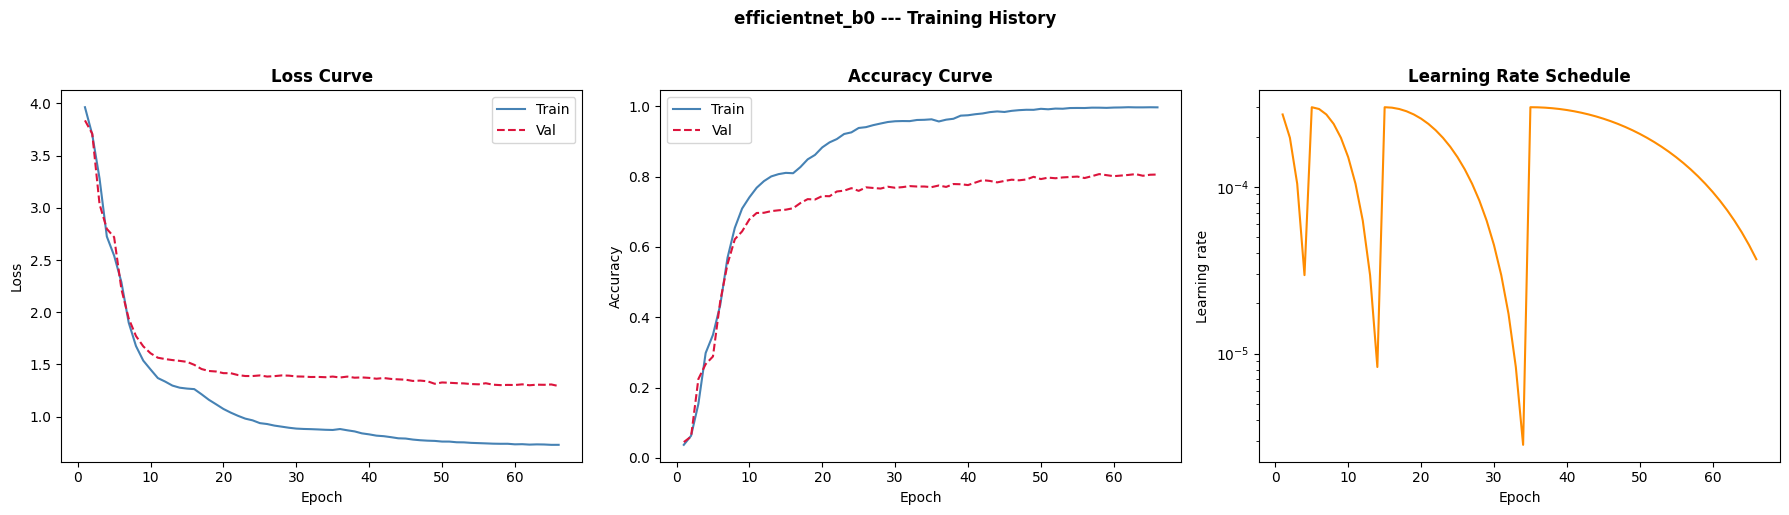

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train', color='steelblue')
ax.plot(epochs_ran, history['val_loss'],   label='Val',   color='crimson', ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve', fontweight='bold')
ax.legend()

ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], label='Train', color='steelblue')
ax.plot(epochs_ran, history['val_acc'],   label='Val',   color='crimson', ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Curve', fontweight='bold')
ax.legend()

ax = axes[2]
ax.plot(epochs_ran, history['lr'], color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_yscale('log')

plt.suptitle(f'{MODEL_NAME} --- Training History', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

---
<a id='8'></a>
## 8. Evaluation --- Test Set

In [ ]:
#Load best checkpoint (same file saved during training)
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded checkpoint (epoch={ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.4f})')

#Run on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)
print(f'\nTest Results:')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')

#Per-class report
present_classes = sorted(set(test_labels))
present_names   = [IDX2CLASS[i] for i in present_classes]
report_str = classification_report(
    test_labels, test_preds,
    labels=present_classes,
    target_names=present_names,
    digits=4
)
print('\nClassification Report:')
print(report_str)

#Save eval metrics to metrics/
eval_metrics = {
    'best_epoch' : int(ckpt['epoch']),
    'val_acc'    : float(best_val_acc),
    'test_loss'  : float(test_loss),
    'test_acc'   : float(test_acc),
}
with open(METRICS_DIR / 'eval_metrics.json', 'w') as f:
    _json.dump(eval_metrics, f, indent=2)
with open(METRICS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report_str)
print(f'Eval metrics saved to {METRICS_DIR}')


Loaded checkpoint (epoch=58, val_acc=0.8071)


  Eval:   0%|          | 0/27 [00:00<?, ?it/s]


Test Results:
  Loss     : 1.3269
  Accuracy : 0.7900  (79.00%)

Classification Report:
                 precision    recall  f1-score   support

           call     0.6809    0.7273    0.7033        44
        dislike     0.7368    0.8400    0.7850        50
           fist     0.7872    0.8043    0.7957        46
           four     0.7292    0.6140    0.6667        57
       grabbing     0.8909    0.8750    0.8829        56
           grip     0.8704    0.8868    0.8785        53
     hand_heart     0.9574    0.9574    0.9574        47
    hand_heart2     0.9400    0.9792    0.9592        48
           holy     1.0000    1.0000    1.0000        61
           like     0.7143    0.5208    0.6024        48
  little_finger     0.8246    0.8246    0.8246        57
  middle_finger     0.7556    0.6538    0.7010        52
           mute     0.6923    0.8182    0.7500        44
     no_gesture     0.8936    0.8571    0.8750        49
             ok     0.5652    0.5098    0.5361        5

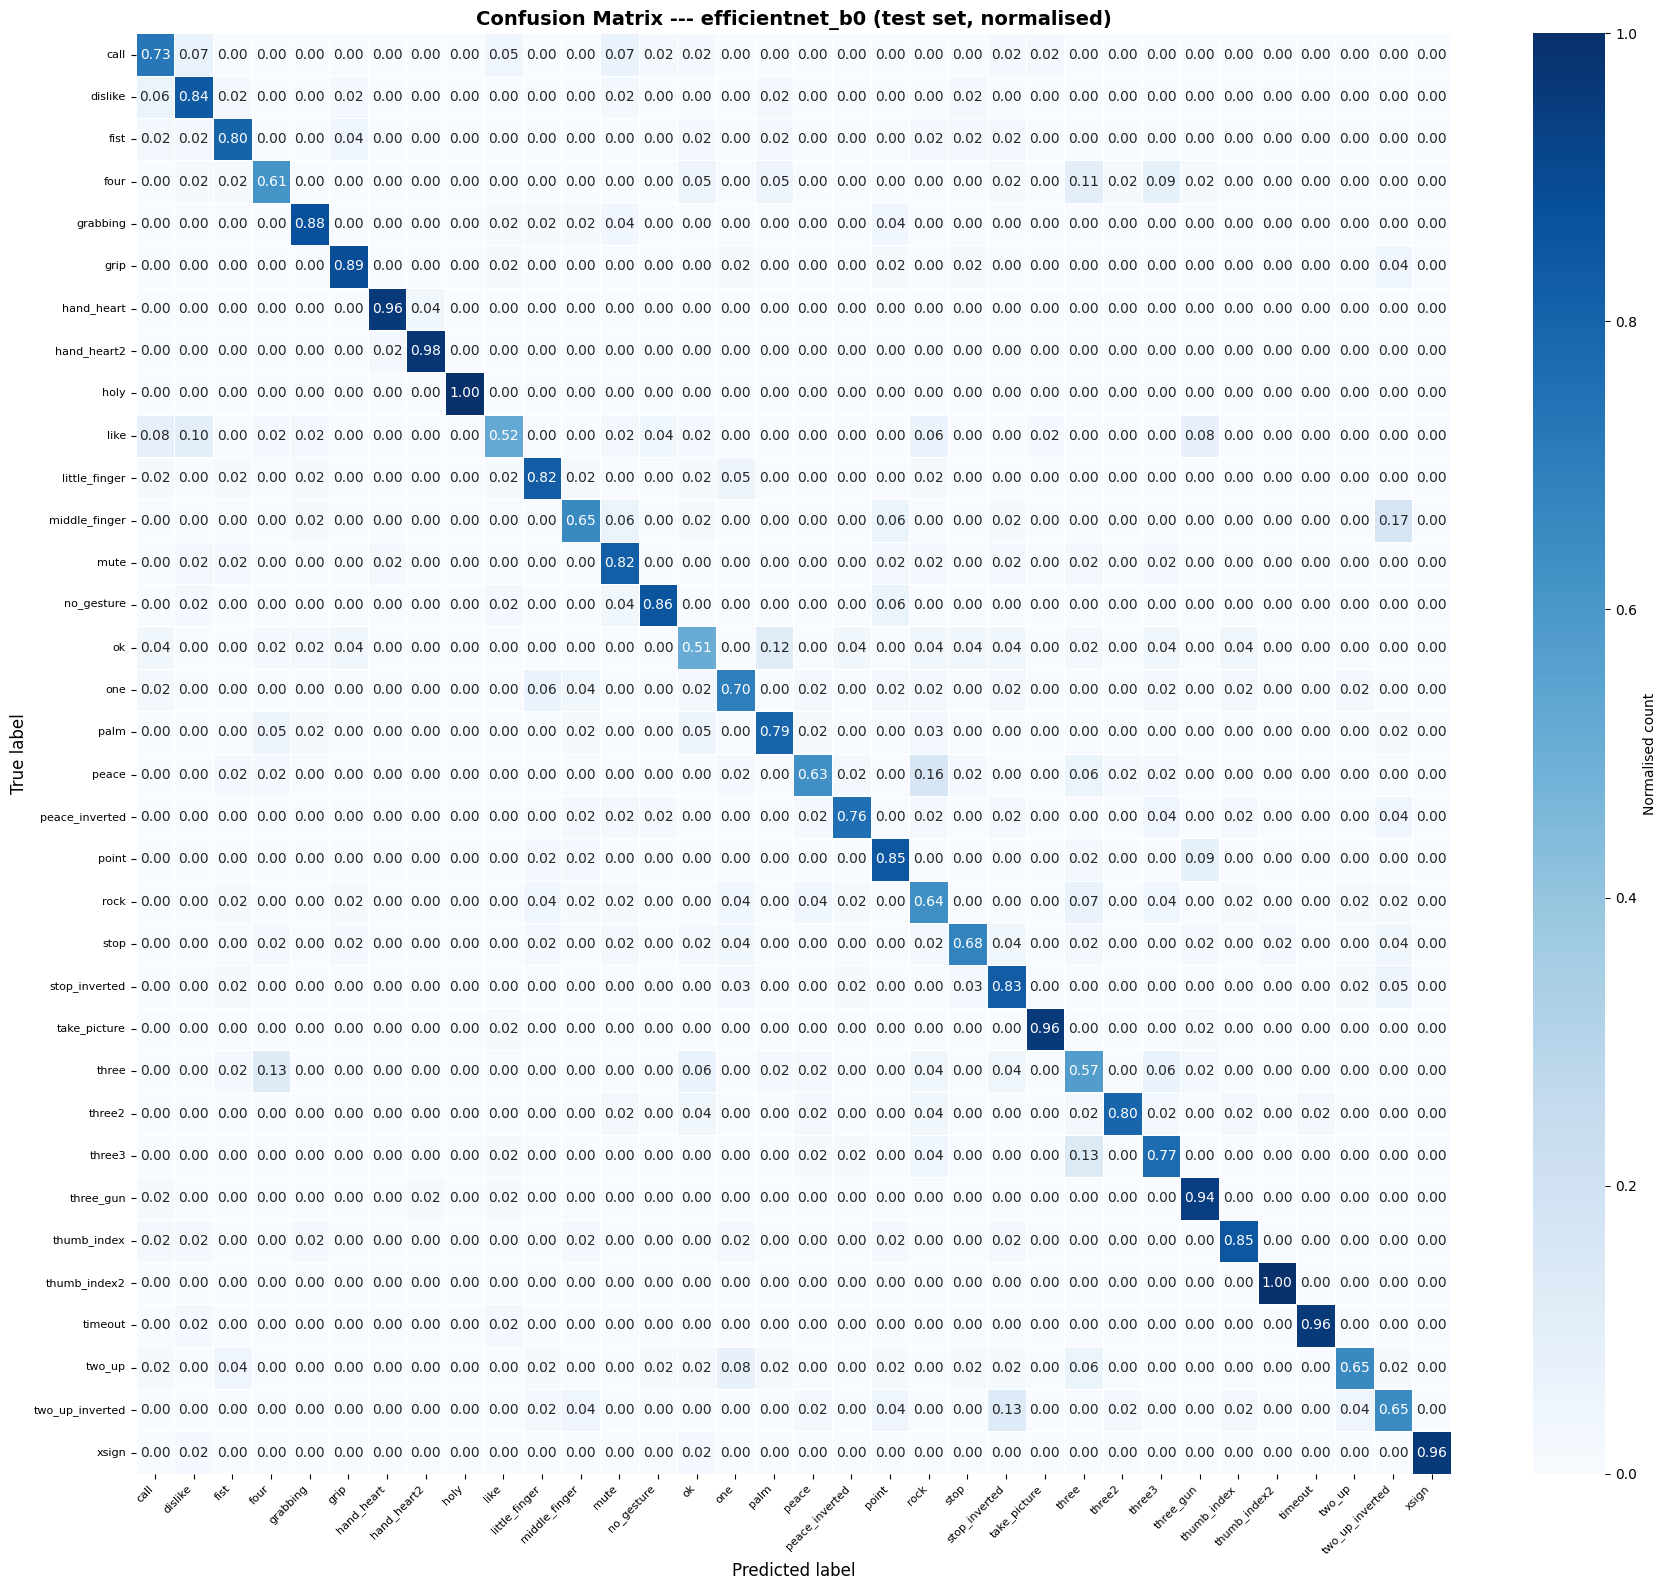

In [ ]:
cm     = confusion_matrix(test_labels, test_preds, labels=present_classes, normalize='true')
cm_df  = pd.DataFrame(cm, index=present_names, columns=present_names)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_df, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Normalised count'},
    ax=ax
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(f'Confusion Matrix --- {MODEL_NAME} (test set, normalised)',
             fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

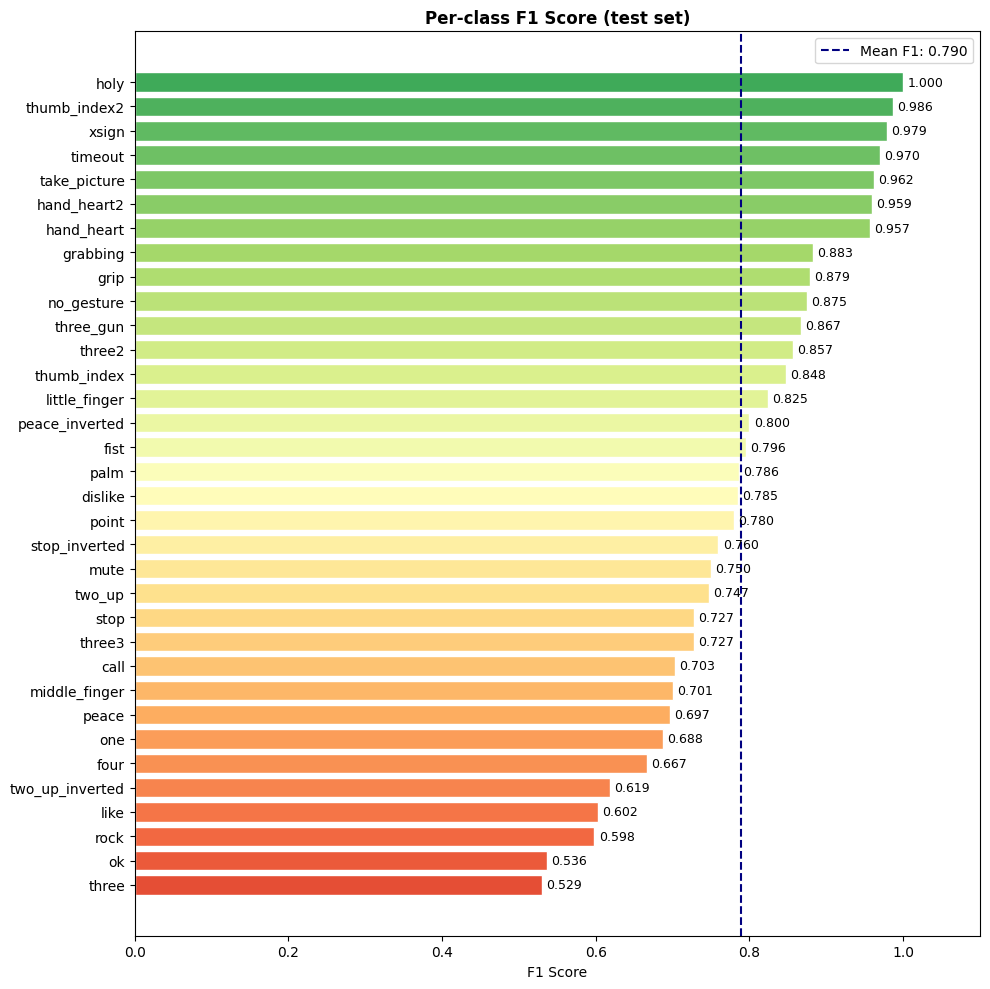

Mean F1  : 0.7896
Worst class: three (0.5294)
Best class : holy (1.0000)
Per-class F1 saved to /content/hagrid_outputs/metrics


In [ ]:
f1_scores = f1_score(test_labels, test_preds, labels=present_classes, average=None)
f1_df     = pd.Series(f1_scores, index=present_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors  = plt.get_cmap('RdYlGn')(np.linspace(0.15, 0.85, len(f1_df)))
bars    = ax.barh(f1_df.index, f1_df.values, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:.3f}' for v in f1_df.values], padding=3, fontsize=9)
ax.set_xlabel('F1 Score')
ax.set_xlim(0, 1.1)
ax.set_title('Per-class F1 Score (test set)', fontweight='bold')
ax.axvline(f1_df.mean(), color='navy', ls='--', lw=1.5,
           label=f'Mean F1: {f1_df.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'per_class_f1.png', bbox_inches='tight')
plt.show()

print(f'Mean F1  : {f1_df.mean():.4f}')
print(f'Worst class: {f1_df.idxmin()} ({f1_df.min():.4f})')
print(f'Best class : {f1_df.idxmax()} ({f1_df.max():.4f})')
#Save per-class F1 to metrics/
f1_dict = {cls: float(score) for cls, score in zip(f1_df.index, f1_df.values)}
with open(METRICS_DIR / 'per_class_f1.json', 'w') as f:
    _json.dump(f1_dict, f, indent=2)
print(f'Per-class F1 saved to {METRICS_DIR}')


---
<a id='9'></a>
## 9. Inference Demo

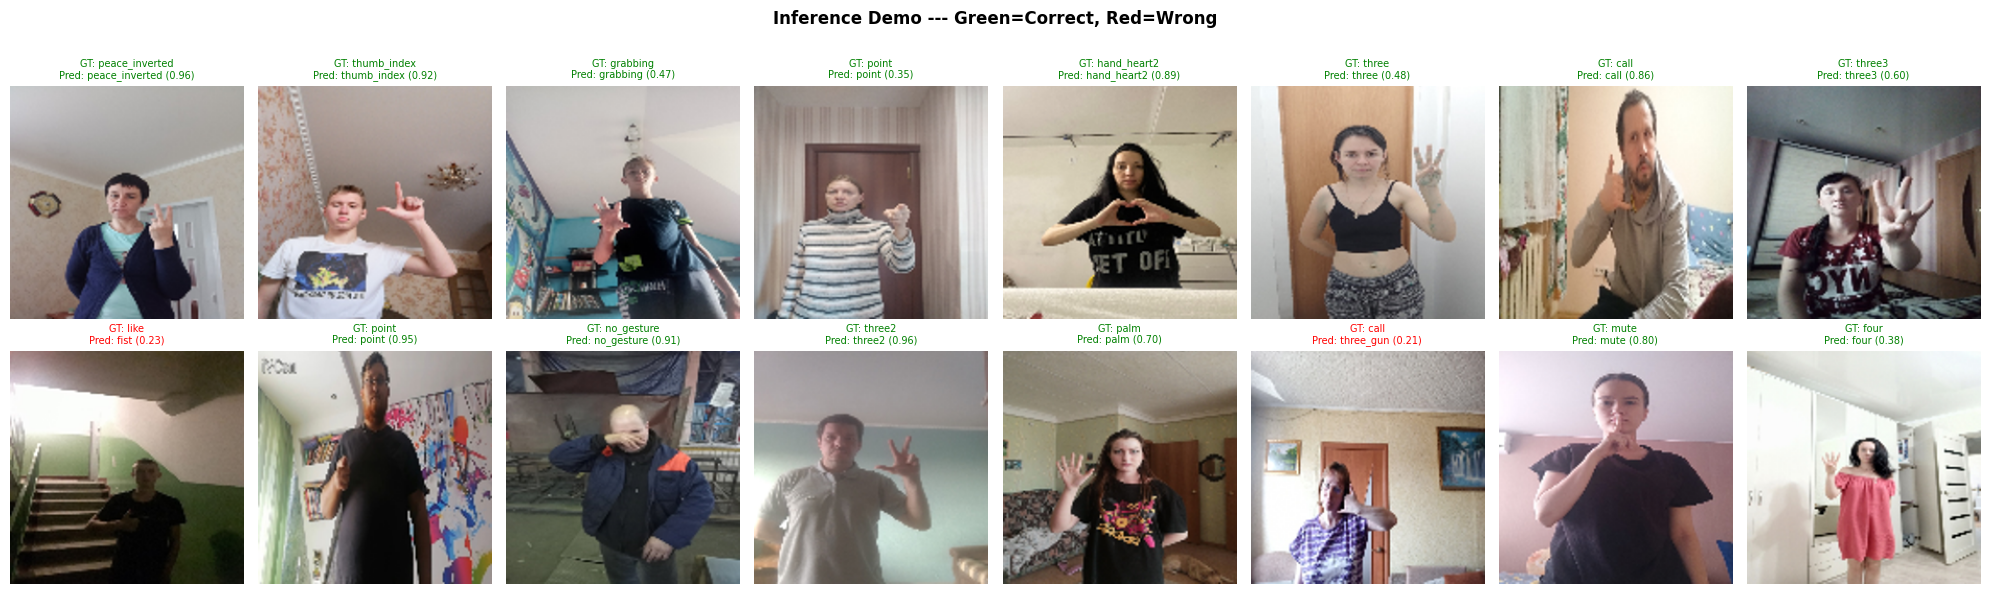

In [ ]:
#Visualise predictions on 16 random validation images
model.eval()

sample_indices = random.sample(range(len(val_images)), 16)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    img        = Image.fromarray(val_images[idx])
    true_label = IDX2CLASS[int(val_labels[idx])]

    tensor = val_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits     = model(tensor)
        probs      = torch.softmax(logits, dim=1)
        pred_idx   = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    pred_label = IDX2CLASS[pred_idx]
    is_correct = true_label == pred_label
    color      = 'green' if is_correct else 'red'

    ax.imshow(img.resize((224, 224)))
    ax.set_title(
        f'GT: {true_label}\nPred: {pred_label} ({confidence:.2f})',
        fontsize=7, color=color
    )
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

plt.suptitle('Inference Demo --- Green=Correct, Red=Wrong', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'inference_demo.png', bbox_inches='tight')
plt.show()


In [ ]:
@torch.no_grad()
def predict_gesture(img_input, model, transform, device, top_k=3):
    """
    Predict gesture for a single image.
    Accepts a file path (str/Path), a PIL Image, or a numpy array.
    Returns a list of (class_name, probability) sorted by confidence.
    """
    if isinstance(img_input, (str, Path)):
        img = Image.open(img_input).convert('RGB')
    elif isinstance(img_input, np.ndarray):
        img = Image.fromarray(img_input).convert('RGB')
    else:
        img = img_input.convert('RGB')

    tensor    = transform(img).unsqueeze(0).to(device)
    logits    = model(tensor)
    probs     = torch.softmax(logits, dim=1)[0].cpu()
    top_probs, top_idxs = probs.topk(top_k)
    return [(IDX2CLASS[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]


#Demo on one validation image
true_label = IDX2CLASS[int(val_labels[0])]
preds      = predict_gesture(val_images[0], model, val_transform, DEVICE)

print(f'True label: {true_label}')
print('Top-3 predictions:')
for cls, prob in preds:
    bar = '#' * int(prob * 40)
    print(f'  {cls:<20} {prob:.4f}  {bar}')


True label: ok
Top-3 predictions:
  ok                   0.8872  ###################################
  stop                 0.0190  
  palm                 0.0127  


---
<a id='10'></a>
## 10. Save Model and Export

In [ ]:
#Checkpoint was saved directly during training as:
#  {MODEL_NAME}_hagrid_final.pth
#No resave needed. Verify it exists:
print(f'Checkpoint : {best_ckpt_path}')
print(f'File size  : {best_ckpt_path.stat().st_size / 1e6:.1f} MB')
print(f'Best epoch : {torch.load(best_ckpt_path, map_location="cpu")["epoch"]}')
print(f'Val acc    : {best_val_acc:.4f}')


Checkpoint : /content/hagrid_checkpoints/efficientnet_b0_hagrid_final.pth
File size  : 49.1 MB
Best epoch : 58
Val acc    : 0.8071


In [ ]:
#Export to ONNX for fast CPU inference (e.g. demo app without PyTorch)
model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
onnx_path   = CKPT_DIR / f'{MODEL_NAME}_hagrid.onnx'

torch.onnx.export(
    model, dummy_input, str(onnx_path),
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}}
)
print(f'ONNX model exported: {onnx_path}')
print(f'File size: {onnx_path.stat().st_size / 1e6:.1f} MB')

/tmp/ipykernel_7439/501538893.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0510 05:48:45.783000 7439 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 05:48:45.784000 7439 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0510 05:48:45.787000 7439 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'f

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported: /content/hagrid_checkpoints/efficientnet_b0_hagrid.onnx
File size: 0.5 MB


In [ ]:
import onnxruntime as ort
import numpy as np

#Same dummy input through both
dummy_np  = np.random.randn(1, 3, 224, 224).astype(np.float32)
dummy_pt  = torch.tensor(dummy_np).to(DEVICE)

#PyTorch output
model.eval()
with torch.no_grad():
    pt_out = torch.softmax(model(dummy_pt), dim=1).cpu().numpy()

#ONNX output
session  = ort.InferenceSession(str(onnx_path))
onnx_out = session.run(None, {'image': dummy_np})[0]
onnx_out = np.exp(onnx_out) / np.exp(onnx_out).sum()  # softmax

#Compare
diff = np.abs(pt_out - onnx_out).max()
print(f'Max difference: {diff:.6f}')   #should be tiny, like 0.000003
print(f'Predicted class PT  : {pt_out.argmax()}')
print(f'Predicted class ONNX: {onnx_out.argmax()}')  #must match

Max difference: 0.000009
Predicted class PT  : 12
Predicted class ONNX: 12


In [ ]:
import zipfile as _zf
import json as _json
import shutil
from ipywidgets import Button, HBox, Output
from IPython.display import display

# -- Build bundle zip (always, needed for both options) --------------------
bundle_zip  = CONTENT_DIR / 'hagrid_training_bundle.zip'
onnx_path   = CKPT_DIR / f'{MODEL_NAME}_hagrid.onnx'

with _zf.ZipFile(bundle_zip, 'w', _zf.ZIP_DEFLATED) as zf:
    zf.write(best_ckpt_path, arcname=f'checkpoints/{best_ckpt_path.name}')
    if onnx_path.exists():
        zf.write(onnx_path, arcname=f'checkpoints/{onnx_path.name}')
    for f in PLOTS_DIR.glob('*.png'):
        zf.write(f, arcname=f'plots/{f.name}')
    for f in METRICS_DIR.glob('*'):
        zf.write(f, arcname=f'metrics/{f.name}')

print(f'Bundle ready: {bundle_zip.stat().st_size / 1e6:.1f} MB')
print('Choose an option below:')

out = Output()

btn_drive = Button(description='Save to Google Drive', button_style='primary', icon='cloud-upload')
btn_zip   = Button(description='Download as ZIP',      button_style='success', icon='download')

def save_to_drive(_):
    with out:
        out.clear_output()
        try:
            DRIVE_DIR = Path('/content/drive/MyDrive/hagrid_training')
            (DRIVE_DIR / 'checkpoints').mkdir(parents=True, exist_ok=True)
            (DRIVE_DIR / 'plots').mkdir(parents=True, exist_ok=True)
            (DRIVE_DIR / 'metrics').mkdir(parents=True, exist_ok=True)

            shutil.copy(best_ckpt_path, DRIVE_DIR / 'checkpoints' / best_ckpt_path.name)
            if onnx_path.exists():
                shutil.copy(onnx_path, DRIVE_DIR / 'checkpoints' / onnx_path.name)
            for f in PLOTS_DIR.glob('*.png'):
                shutil.copy(f, DRIVE_DIR / 'plots' / f.name)
            for f in METRICS_DIR.glob('*'):
                shutil.copy(f, DRIVE_DIR / 'metrics' / f.name)

            print(f'Saved to Google Drive: {DRIVE_DIR}')
            print('  checkpoints/')
            for f in sorted((DRIVE_DIR / 'checkpoints').iterdir()):
                print(f'    {f.name}')
            print('  plots/')
            for f in sorted((DRIVE_DIR / 'plots').iterdir()):
                print(f'    {f.name}')
            print('  metrics/')
            for f in sorted((DRIVE_DIR / 'metrics').iterdir()):
                print(f'    {f.name}')
        except Exception as e:
            print(f'Drive save failed: {e}')

def download_zip(_):
    with out:
        out.clear_output()
        try:
            from google.colab import files
            files.download(str(bundle_zip))
            print('Download started.')
        except Exception as e:
            print(f'Download failed: {e}')

btn_drive.on_click(save_to_drive)
btn_zip.on_click(download_zip)

display(HBox([btn_drive, btn_zip]), out)


Bundle ready: 47.9 MB
Choose an option below:


Output()

In [ ]:
# (This cell intentionally left empty — export handled by the buttons above)


In [ ]:
eval_m = _json.load(open(METRICS_DIR / 'eval_metrics.json'))

print('=' * 55)
print('  TRAINING SUMMARY')
print('=' * 55)
print(f'  Model          : {MODEL_NAME}')
print(f'  Dataset        : HaGRIDv2, 34 classes, 500/class')
print(f'  Input size     : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Best epoch     : {eval_m["best_epoch"]}')
print(f'  Best val acc   : {eval_m["val_acc"]:.4f}  ({eval_m["val_acc"]*100:.2f}%)')
print(f'  Test accuracy  : {eval_m["test_acc"]:.4f}  ({eval_m["test_acc"]*100:.2f}%)')
print(f'  Checkpoint     : {best_ckpt_path.name}')
print(f'  ONNX model     : {MODEL_NAME}_hagrid.onnx')
print('=' * 55)
print('  Output structure:')
print('    hagrid_checkpoints/')
print(f'      {MODEL_NAME}_hagrid_final.pth')
print(f'      {MODEL_NAME}_hagrid.onnx')
print('    hagrid_outputs/')
print('      plots/    sample_batch.png  training_curves.png')
print('                confusion_matrix.png  per_class_f1.png')
print('                inference_demo.png')
print('      metrics/  training_history.json  eval_metrics.json')
print('                per_class_f1.json  classification_report.txt')


  TRAINING SUMMARY
  Model          : efficientnet_b0
  Dataset        : HaGRIDv2, 34 classes, 500/class
  Input size     : 224x224
  Best epoch     : 58
  Best val acc   : 0.8071  (80.71%)
  Test accuracy  : 0.7900  (79.00%)
  Checkpoint     : efficientnet_b0_hagrid_final.pth
  ONNX model     : efficientnet_b0_hagrid.onnx
  Output structure:
    hagrid_checkpoints/
      efficientnet_b0_hagrid_final.pth
      efficientnet_b0_hagrid.onnx
    hagrid_outputs/
      plots/    sample_batch.png  training_curves.png
                confusion_matrix.png  per_class_f1.png
                inference_demo.png
      metrics/  training_history.json  eval_metrics.json
                per_class_f1.json  classification_report.txt


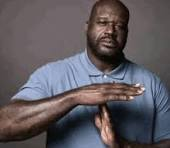

timeout              0.2901
three_gun            0.1324
no_gesture           0.0654


In [ ]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import torchvision.transforms as T
import cv2
from google.colab.patches import cv2_imshow

# 1. Load the model
session = ort.InferenceSession('/content/hagrid_checkpoints/efficientnet_b0_hagrid.onnx')

# 2. Same transform as val (no augmentation)
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# 3. Class names — must match training order
IDX2CLASS = {
    0: 'call', 1: 'dislike', 2: 'fist', 3: 'four',
    4: 'grabbing', 5: 'grip', 6: 'hand_heart', 7: 'hand_heart2',
    8: 'holy', 9: 'like', 10: 'little_finger', 11: 'middle_finger',
    12: 'mute', 13: 'no_gesture', 14: 'ok', 15: 'one',
    16: 'palm', 17: 'peace', 18: 'peace_inverted', 19: 'point',
    20: 'rock', 21: 'stop', 22: 'stop_inverted', 23: 'take_picture',
    24: 'three', 25: 'three2', 26: 'three3', 27: 'three_gun',
    28: 'thumb_index', 29: 'thumb_index2', 30: 'timeout',
    31: 'two_up', 32: 'two_up_inverted', 33: 'xsign'
}

# 4. Infer on a single image
def predict(image_path, top_k=3):
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).numpy()  # (1, 3, 224, 224)

    logits = session.run(None, {'image': tensor})[0]  # (1, 34)
    probs  = np.exp(logits) / np.exp(logits).sum()    # softmax

    top_idx = probs[0].argsort()[::-1][:top_k]
    return [(IDX2CLASS[i], float(probs[0][i])) for i in top_idx]

# 5. Use it
cv2_imshow(cv2.imread('/content/download.jpg'))
results = predict('download.jpg')
for cls, prob in results:
    print(f'{cls:<20} {prob:.4f}')